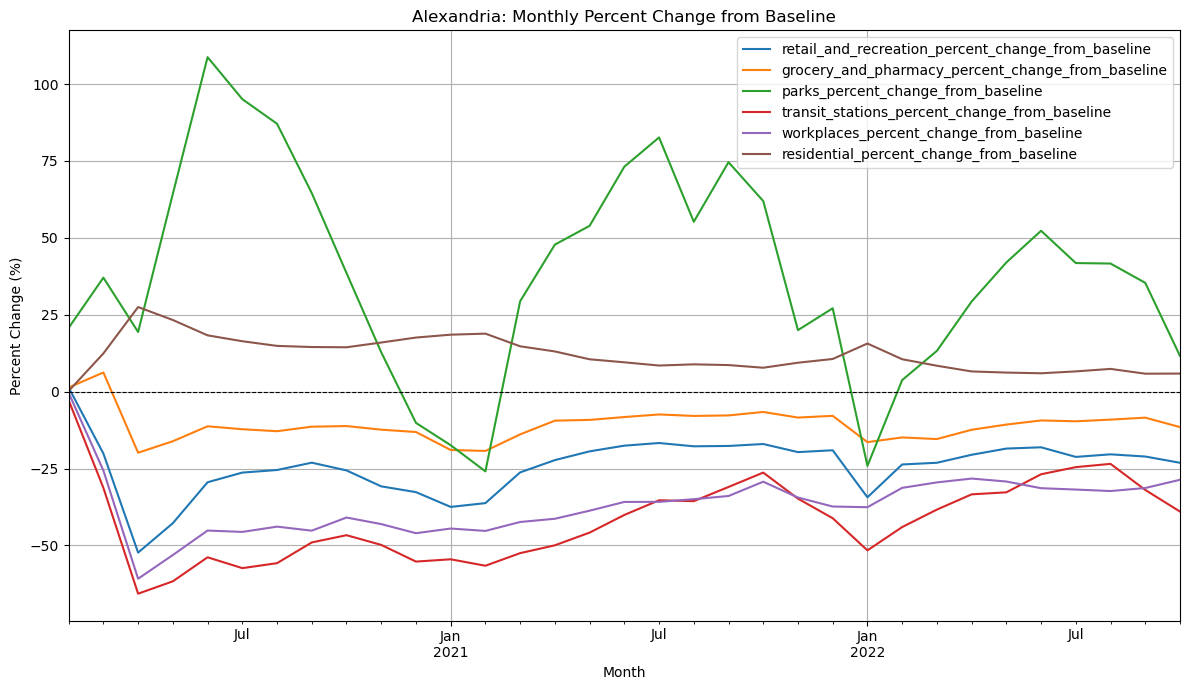

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

mobility = pd.read_csv("va_mobility.csv")
mobility['date'] = pd.to_datetime(mobility['date'])

alexandria = mobility[mobility["sub_region_2"] == "Alexandria"].copy()
alexandria["year_month"] = alexandria["date"].dt.to_period('M')

alex_cols = [
    "retail_and_recreation_percent_change_from_baseline", 
    "grocery_and_pharmacy_percent_change_from_baseline", 
    "parks_percent_change_from_baseline", 
    "transit_stations_percent_change_from_baseline", 
    "workplaces_percent_change_from_baseline", 
    "residential_percent_change_from_baseline"
]
monthly = alexandria.groupby("year_month")[alex_cols].mean()


fig, ax = plt.subplots(figsize=(12, 7))

monthly.plot(ax=ax)

ax.set_title("Alexandria: Monthly Percent Change from Baseline")
ax.set_xlabel("Month")
ax.set_ylabel("Percent Change (%)")
ax.grid(True) 
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout() 
plt.show()






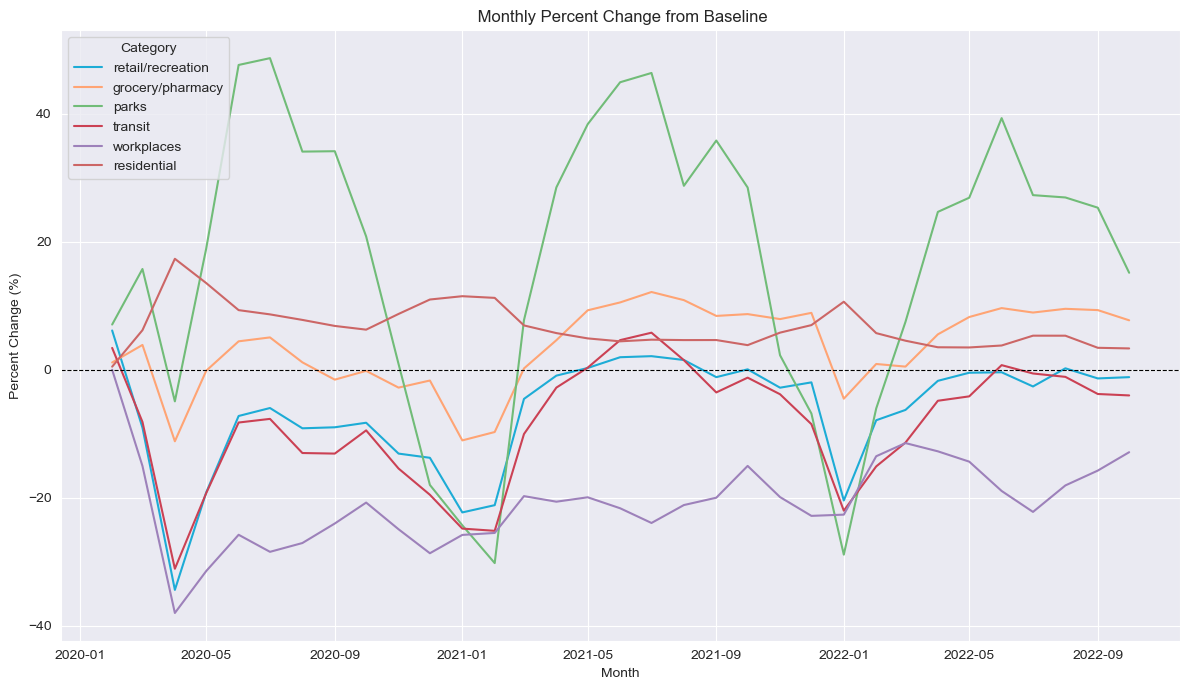

In [37]:
# overall cat trends
import seaborn as sns

mobility_cats = mobility.copy()
mobility_cats["year_month"] = mobility_cats["date"].dt.to_period('M')


cat_cols = [
    "retail_and_recreation_percent_change_from_baseline", 
    "grocery_and_pharmacy_percent_change_from_baseline", 
    "parks_percent_change_from_baseline", 
    "transit_stations_percent_change_from_baseline", 
    "workplaces_percent_change_from_baseline", 
    "residential_percent_change_from_baseline"
]
monthly_mob = mobility_cats.groupby("year_month")[cat_cols].mean()
monthly_mob.index = monthly_mob.index.to_timestamp()

monthly_mob_long = (
    monthly_mob
    .reset_index()
    .melt(id_vars="year_month", value_vars=cat_cols,
          var_name="category", value_name="percent_change")
)

monthly_mob_long["category_short"] = monthly_mob_long["category"].replace({
    "retail_and_recreation_percent_change_from_baseline":"retail/recreation", 
    "grocery_and_pharmacy_percent_change_from_baseline":"grocery/pharmacy", 
    "parks_percent_change_from_baseline":"parks", 
    "transit_stations_percent_change_from_baseline":"transit", 
    "workplaces_percent_change_from_baseline":"workplaces", 
    "residential_percent_change_from_baseline":"residential"
    }
)

palette = sns.crayon_palette(["Cerulean", "Atomic Tangerine", "Fern", "Brick Red", "Purple Mountains' Majesty", "Fuzzy Wuzzy"])

fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=monthly_mob_long, 
    x="year_month", 
    y="percent_change", 
    hue="category_short", palette=palette
)
ax.legend(title="Category", loc="upper left", fontsize=10, title_fontsize=10)


ax.set_title(" Monthly Percent Change from Baseline")
ax.set_xlabel("Month")
ax.set_ylabel("Percent Change (%)")
ax.grid(True) 
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout() 
plt.show()


In [29]:
# rural v urban
rural_counties = ["Accomack County","Alleghany County","Bath County",
                  "Bland County","Brunswick County","Buchanan County",
                  "Carroll County","Charlotte County","Craig County",
                  "Dickenson County","Essex County","Grayson County",
                  "Greensville County","Halifax County","Henry County",
                  "Highland County","Lee County","Louisa County",
                  "Lunenburg County","Madison County","Mecklenburg County",
                  "Middlesex County","Montgomery County","Nelson County",
                  "Northampton County","Northumberland County","Patrick County",
                  "Pittsylvania County","Prince Edward County","Pulaski County",
                  "Richmond County","Rockbridge County","Rockingham County",
                  "Russell County","Smyth County","Southampton County",
                  "Tazewell County","Wise County","Wythe County","Shenandoah County"]

rural_mobility = mobility[mobility["sub_region_2"].isin(rural_counties)]
metro_mobility = mobility[-mobility["sub_region_2"].isin(rural_counties)]

# rural
rural_mobility.loc[:,"year_month"] = rural_mobility["date"].dt.to_period('M')

monthly_mob_rural = rural_mobility.groupby("year_month")[cat_cols].mean()
monthly_mob_rural = monthly_mob_rural.sort_index()

# metro
metro_mobility.loc[:,"year_month"] = metro_mobility["date"].dt.to_period('M')

monthly_mob_metro = metro_mobility.groupby("year_month")[cat_cols].mean()
monthly_mob_metro = monthly_mob_metro.sort_index()
monthly_mob_metro.index = monthly_mob_metro.index.to_timestamp()




/var/folders/lv/9m_qv53944x04_1mpk21jgtc0000gn/T/ipykernel_72221/2143101534.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rural_mobility.loc[:,"year_month"] = rural_mobility["date"].dt.to_period('M')
/var/folders/lv/9m_qv53944x04_1mpk21jgtc0000gn/T/ipykernel_72221/2143101534.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metro_mobility.loc[:,"year_month"] = metro_mobility["date"].dt.to_period('M')


In [30]:
print(rural_mobility.shape)
print(mobility.shape)
print(metro_mobility.shape)



(32882, 16)
(157834, 15)
(124952, 16)


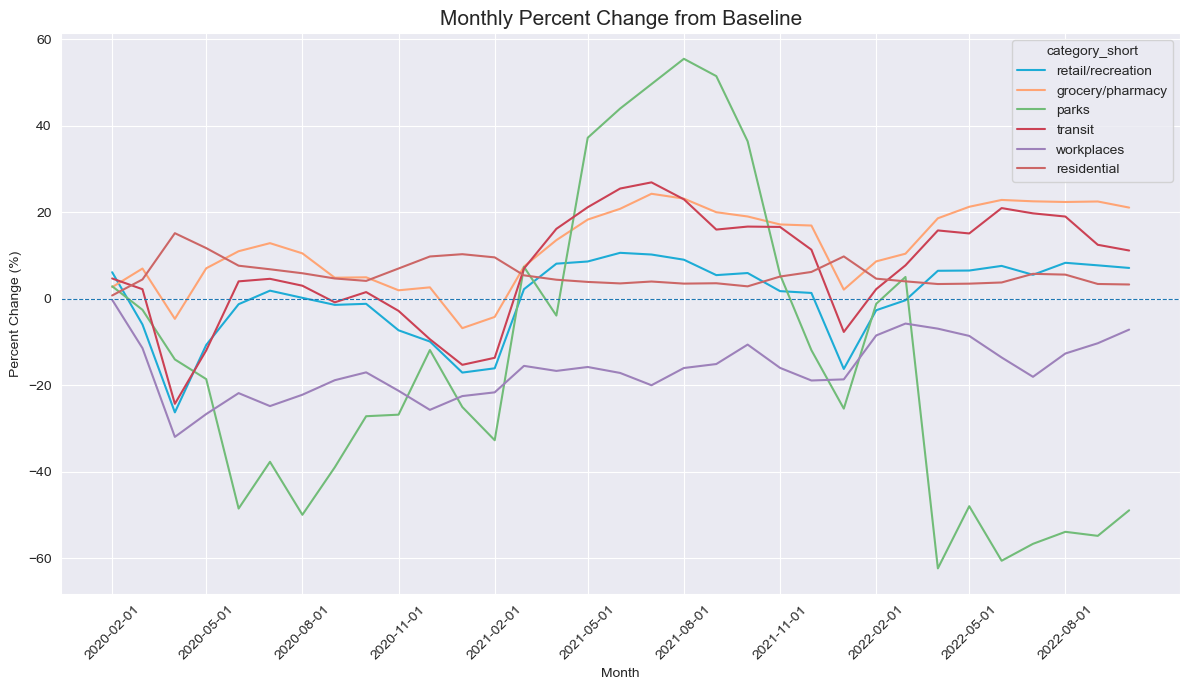

In [44]:
import seaborn as sns


monthly_r = (
    monthly_mob_rural
    .reset_index()
    .melt(id_vars="year_month", value_vars=cat_cols,
          var_name="category", value_name="percent_change")
)

monthly_r["category_short"] = monthly_r["category"].replace({
    "retail_and_recreation_percent_change_from_baseline":"retail/recreation", 
    "grocery_and_pharmacy_percent_change_from_baseline":"grocery/pharmacy", 
    "parks_percent_change_from_baseline":"parks", 
    "transit_stations_percent_change_from_baseline":"transit", 
    "workplaces_percent_change_from_baseline":"workplaces", 
    "residential_percent_change_from_baseline":"residential"
    }
)


palette = sns.crayon_palette(["Cerulean", "Atomic Tangerine", "Fern", "Brick Red", "Purple Mountains' Majesty", "Fuzzy Wuzzy"])

fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(data=monthly_r, x="year_month", y="percent_change", hue="category_short", palette=palette)


plt.title("Monthly Percent Change from Baseline", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Percent Change (%)")
plt.grid(True)
plt.axhline(0, linestyle='--', linewidth=0.8)

plt.xticks(rotation=45, fontsize=10)
ax.set_xticks(monthly_r["year_month"].unique()[::3])


plt.tight_layout()
plt.show()

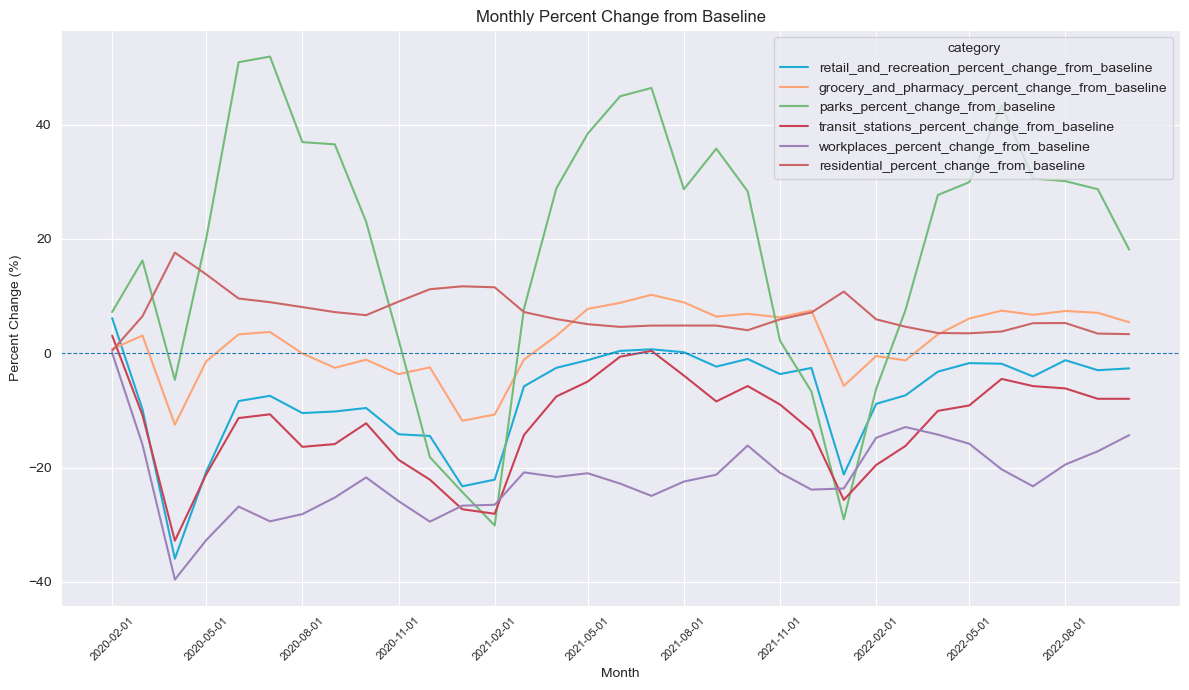

In [ ]:

monthly_m = (
    monthly_mob_metro
    .reset_index()
    .melt(id_vars="year_month", value_vars=cat_cols,
          var_name="category", value_name="percent_change")
)


palette = sns.crayon_palette(["Cerulean", "Atomic Tangerine", "Fern", "Brick Red", "Purple Mountains' Majesty", "Fuzzy Wuzzy"])

fig, ax = plt.subplots(figsize=(12, 7))
sns.set_style(style="darkgrid")
sns.lineplot(data=monthly_m, x="year_month", y="percent_change", hue="category", palette=palette)


plt.title("Monthly Percent Change from Baseline")
plt.xlabel("Month")
plt.ylabel("Percent Change (%)")
plt.grid(True)
plt.axhline(0, linestyle='--', linewidth=0.8)

plt.xticks(rotation=45, fontsize=8)
ax.set_xticks(monthly_m["year_month"].unique()[::3])


plt.tight_layout()
plt.show()

In [33]:
list(sns.palettes.crayons.keys())


['Almond',
 'Antique Brass',
 'Apricot',
 'Aquamarine',
 'Asparagus',
 'Atomic Tangerine',
 'Banana Mania',
 'Beaver',
 'Bittersweet',
 'Black',
 'Blue',
 'Blue Bell',
 'Blue Green',
 'Blue Violet',
 'Blush',
 'Brick Red',
 'Brown',
 'Burnt Orange',
 'Burnt Sienna',
 'Cadet Blue',
 'Canary',
 'Caribbean Green',
 'Carnation Pink',
 'Cerise',
 'Cerulean',
 'Chestnut',
 'Copper',
 'Cornflower',
 'Cotton Candy',
 'Dandelion',
 'Denim',
 'Desert Sand',
 'Eggplant',
 'Electric Lime',
 'Fern',
 'Forest Green',
 'Fuchsia',
 'Fuzzy Wuzzy',
 'Gold',
 'Goldenrod',
 'Granny Smith Apple',
 'Gray',
 'Green',
 'Green Yellow',
 'Hot Magenta',
 'Inchworm',
 'Indigo',
 'Jazzberry Jam',
 'Jungle Green',
 'Laser Lemon',
 'Lavender',
 'Macaroni and Cheese',
 'Magenta',
 'Mahogany',
 'Manatee',
 'Mango Tango',
 'Maroon',
 'Mauvelous',
 'Melon',
 'Midnight Blue',
 'Mountain Meadow',
 'Navy Blue',
 'Neon Carrot',
 'Olive Green',
 'Orange',
 'Orchid',
 'Outer Space',
 'Outrageous Orange',
 'Pacific Blue',
 'Pe